In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import oncapintada as onca

from mace.calculators import  MACECalculator
from ase.io import write, read
from ase.optimize import BFGS
from ase.filters import UnitCellFilter
from ase.build import bulk
from ase.phonons import Phonons

import seaborn as sns
sns.set_style("ticks")

                                           
          ▄▖          ▘  ▗    ▌            
          ▌▌▛▌▛▘▀▌▄▖▛▌▌▛▌▜▘▀▌▛▌▀▌          
          ▙▌▌▌▙▖█▌  ▙▌▌▌▌▐▖█▌▙▌█▌          
                    ▌                      
                                           
    version: 26.4.9                 
    developed by: Leandro Seixas             
    homepage: https://github.com/seixasgroup/oncapintada
                                                  
--------------------------------------------------
                                                  
System:
├── architecture: arm64
├── platform: Darwin
├── user: leseixas
├── hostname: safira
├── cwd: /Users/leseixas/Library/CloudStorage/Dropbox/Repositories/oncapintada/examples/notebooks/example02
└── PID: 77641
                                               
Python:
├── version: 3.13.2 | packaged by conda-forge | (main, Feb 14 2025, 08:14:38) [Clang 18.1.8 ]      
└── executable: /Users/leseixas/miniconda3/envs/mace/bin/python      
 

In [2]:
# onca.starter()

In [2]:
# MACE-matpes-pbe-omat-ft.model | MACE-matpes-r2scan-omat-ft.model | mace-omat-0-medium.model
# model = "mace-omat-0-medium.model"
model = "MACE-matpes-pbe-omat-ft.model"
calc = MACECalculator(model_paths=f"/Users/leseixas/.local/mace/{model}",
                      device='cpu',
                      default_dtype='float32')

Default dtype float32 does not match model dtype float64, converting models to float32.


# Enthalpy of mixing

In [3]:
# Supercell size for dilute alloy calculations
sc = [2,2,2]

In [4]:
atomsAA = bulk("Au", cubic=True).repeat(sc)

atomsAA.calc = calc

varcell = UnitCellFilter(atomsAA)
optim = BFGS(varcell)
optim.run(fmax=0.01)
energy_AA = atomsAA.get_total_energy()

      Step     Time          Energy          fmax
BFGS:    0 19:35:23     -102.537689        0.786695
BFGS:    1 19:35:23     -102.563858        0.768607
BFGS:    2 19:35:23     -102.931595        0.461600
BFGS:    3 19:35:23     -103.123062        0.180794
BFGS:    4 19:35:23     -103.160049        0.012279
BFGS:    5 19:35:24     -103.160202        0.000344


In [5]:
atomsBB = bulk("Pt", cubic=True).repeat(sc)

atomsBB.calc = calc

varcell = UnitCellFilter(atomsBB)
optim = BFGS(varcell)
optim.run(fmax=0.01)

energy_BB = atomsBB.get_total_energy()

      Step     Time          Energy          fmax
BFGS:    0 19:35:25     -194.868240        0.435937
BFGS:    1 19:35:26     -194.876221        0.423876
BFGS:    2 19:35:26     -195.016724        0.048116
BFGS:    3 19:35:26     -195.018661        0.001610


In [6]:
# doping Au with Pt
atomsBA = atomsAA.copy()
atomsBA[0].symbol = "Pt"
atomsBA.calc = calc

varcell = UnitCellFilter(atomsBA)
optim = BFGS(varcell)
optim.run(fmax=0.01)
energy_BA = atomsBA.get_total_energy()

      Step     Time          Energy          fmax
BFGS:    0 19:35:27     -105.810272        0.168265
BFGS:    1 19:35:28     -105.815071        0.148210
BFGS:    2 19:35:28     -105.832169        0.056330
BFGS:    3 19:35:28     -105.832390        0.055653
BFGS:    4 19:35:28     -105.833862        0.045255
BFGS:    5 19:35:28     -105.834366        0.036921
BFGS:    6 19:35:28     -105.834709        0.029409
BFGS:    7 19:35:28     -105.834991        0.025763
BFGS:    8 19:35:29     -105.835510        0.019410
BFGS:    9 19:35:29     -105.835983        0.015116
BFGS:   10 19:35:29     -105.836197        0.006230


In [7]:
# doping Pt with Au
atomsAB = atomsBB.copy()
atomsAB[0].symbol = "Au"
atomsAB.calc = calc

varcell = UnitCellFilter(atomsAB)
optim = BFGS(varcell)
optim.run(fmax=0.01)
energy_AB = atomsAB.get_total_energy()

      Step     Time          Energy          fmax
BFGS:    0 19:35:31     -191.780396        0.275317
BFGS:    1 19:35:31     -191.792419        0.213245
BFGS:    2 19:35:31     -191.811798        0.087318
BFGS:    3 19:35:31     -191.812225        0.084576
BFGS:    4 19:35:31     -191.814545        0.062171
BFGS:    5 19:35:31     -191.815460        0.048887
BFGS:    6 19:35:32     -191.816467        0.048770
BFGS:    7 19:35:32     -191.817291        0.044101
BFGS:    8 19:35:32     -191.818024        0.023223
BFGS:    9 19:35:32     -191.818298        0.007121


In [8]:
# row is solute, column is solvent
energy_matrix = np.array(
    [ [ energy_AA, energy_AB ],
      [ energy_BA, energy_BB ] ]
)

print("Energy matrix (eV):")
print(energy_matrix)

Energy matrix (eV):
[[-103.16020203 -191.81829834]
 [-105.8361969  -195.0186615 ]]


In [9]:
dilution = 1 / len(atomsAA)
print(f"Dilution: {dilution:.4f}")

mixing_model = onca.BinaryAlloy(energy_matrix=energy_matrix, dilution = dilution)

Mij = mixing_model.get_Mij()
print("Mij:")
print(Mij * 96.485) # in kJ/mol

x = np.linspace(0, 1, 101)

h_mix = mixing_model.get_enthalpy_of_mixing(x=x)

Dilution: 0.0312
Mij:
[[ 0.         31.81943122]
 [18.77424287  0.        ]]


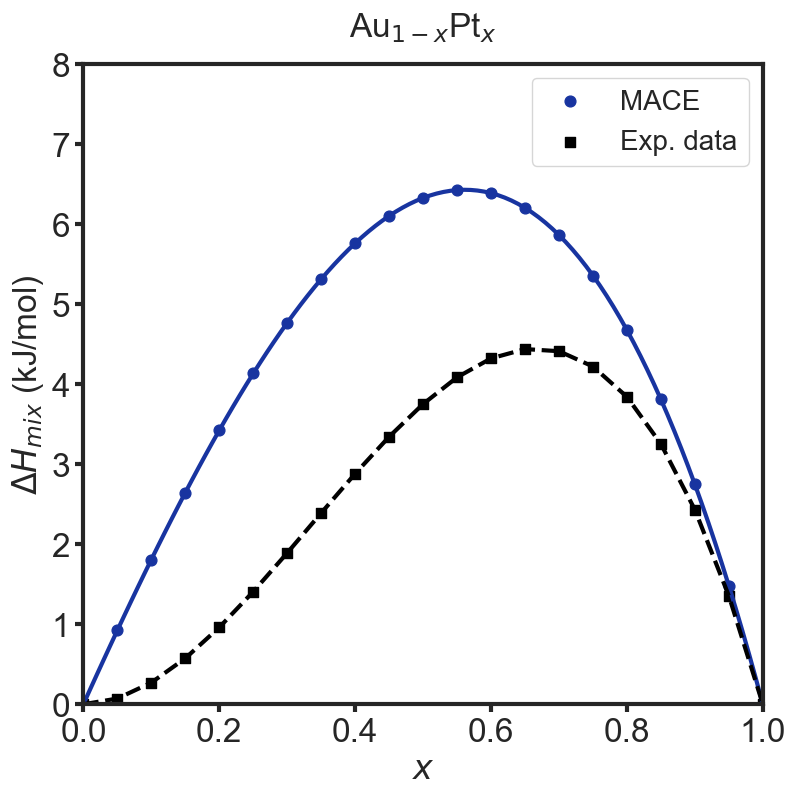

In [11]:
fig, ax = plt.subplots(1,1, figsize=(8,8))
lw = 3
fontsize = 24
markersize = 60
color1="#1834A0"
color2="#003366"


# Calculated enthalpy of mixing
ax.plot(x, h_mix, color=color1, linewidth=lw)
ax.scatter(x[::5], h_mix[::5], color=color1, s=markersize, label="MACE")

# Plot experimental data with pandas
exp_data = pd.read_csv("../../experimental_data/enthalpy/AuPt.csv")
ax.plot(exp_data["x"], exp_data["enthalpy"], "--", color="black", linewidth=lw)
ax.scatter(exp_data["x"], exp_data["enthalpy"], color="black", s=markersize, marker="s", label="Exp. data") # square markers


ax.set_xlabel("$x$", fontsize=fontsize)
ax.set_ylabel(r"$\Delta H_{mix}$ (kJ/mol)", fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_ylim(0,8)

# Setting axes properties
ax.tick_params(axis='both', direction='out', which='major', labelsize=fontsize, width=lw, length=6, zorder=5)
for spine in ax.spines.values():
    spine.set_linewidth(lw)

plt.legend(fontsize=20, loc="upper right")
plt.title(r"Au$_{1-x}$Pt$_{x}$", fontsize=24, pad=20)
plt.tight_layout()
fig.savefig("AuPt_mixing_enthalpy.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()


# Gibbs free energy of mixing

In [10]:
ntemp = 201
ncomp = 1001

temperatures = np.linspace(0, 2000, ntemp)
print(f"Temperatures: from {temperatures[0]} K to {temperatures[-1]} K with {len(temperatures)} points")

x = np.linspace(0, 1, ncomp)
eps = 1e-8
x = np.clip(x, eps, 1-eps) # Avoid log(0) issues
print(f"Compositions: from {x[0]} to {x[-1]} with {len(x)} points")

Temperatures: from 0.0 K to 2000.0 K with 201 points
Compositions: from 1e-08 to 0.99999999 with 1001 points


In [11]:
enthalpy = mixing_model.get_enthalpy_of_mixing(x=x)

entropy = mixing_model.get_configurational_entropy(x=x)

gibbs_free_energy = mixing_model.get_gibbs_free_energy_of_mixing(x=x, t=temperatures)

In [13]:
gibbs_df = pd.DataFrame(gibbs_free_energy, index=x, columns=temperatures, dtype=np.float64)
gibbs_df.index.name = 'x'
gibbs_df.columns.name = 't'
gibbs_df.to_csv("gibbs_free_energy_of_mixing.csv")

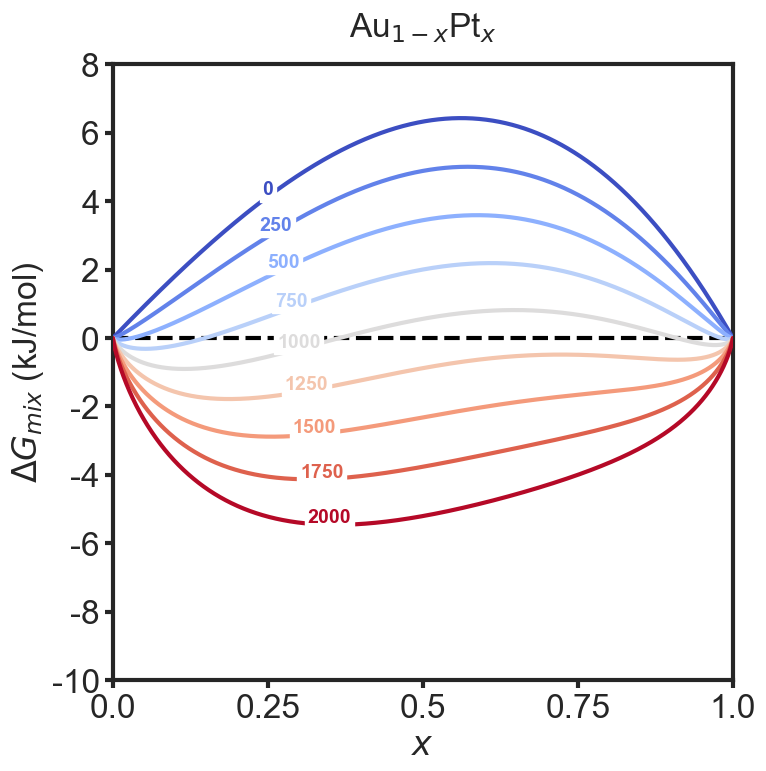

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

fontsize=24
lw=3
ntemp = gibbs_free_energy.shape[1]

colors = sns.color_palette("coolwarm", n_colors=ntemp)              # Options: "RdBu_r"

# Baseline black dased line at G=0
ax.axhline(0, color='black', linestyle='--', linewidth=lw, zorder=1)

every = 25
for i in range(ntemp)[::every]:                                        # Plot every n temperatures for clarity
    ax.plot(x, gibbs_free_energy[:, i], color=colors[i], lw=lw, zorder=3)
    x_pos = 0.25 + i/ntemp * 0.1                                    # Position the label along the x-axis
    y_pos = np.interp(x_pos, x, gibbs_free_energy[:, i]) + 0.2      # Interpolate to find the y position at x_pos
    ax.text(x_pos, y_pos , str(int(temperatures[i])), 
            color=colors[i], 
            fontsize=14,
            fontweight='bold',
            ha='center',
            va='center',
            backgroundcolor='white',
            bbox=dict(facecolor='white', edgecolor='white', pad=2.0, alpha=1.0))

ax.set_xlabel(r"$x$", fontsize=fontsize)
ax.set_ylabel(r"$\Delta G_{mix}$ (kJ/mol)", fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_xticks(np.linspace(0, 1, 5))
ax.set_xticklabels(np.linspace(0, 1, 5), fontsize=fontsize)
emin, emax = -10, 10
estep = 2
ax.set_yticks(np.arange(emin, emax, estep))
ax.set_yticklabels(np.arange(emin, emax, estep), fontsize=fontsize)

plt.title(r"Au$_{1-x}$Pt$_{x}$", fontsize=24, pad=20)
# ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=fontsize, width=lw, length=6, direction='out')
for spine in ax.spines.values():
    spine.set_linewidth(lw)

fig.savefig('gibbs_free_energy_of_mixing.png', dpi=600, bbox_inches='tight')
plt.show()

# Phase diagram

In [14]:
phase_diagram = onca.PhaseDiagram(gibbs_df)


In [17]:
# Binodal curve
binodal_curve = phase_diagram.binodal_curve(ninterp=10)
binodal_curve.head()

,x,t
0,1.000000e-08,0.0
1,1.000000e-08,110.0
2,1.000000e-08,120.0
3,1.000000e-08,130.0
4,1.000000e-08,140.0


In [15]:
# Spinodal curve
spinodal_curve = phase_diagram.spinodal_curve()
spinodal_curve.head()

,x,t
0,0.007076,10.0
1,0.013534,20.0
2,0.019625,30.0
3,0.025412,40.0
4,0.030932,50.0


In [16]:
# Critical point
critical_point = phase_diagram.critical_point()
print("Critical point:")
print(critical_point)

Critical point:
{'x_c': 0.6204617723808196, 't_c': 1700.0}


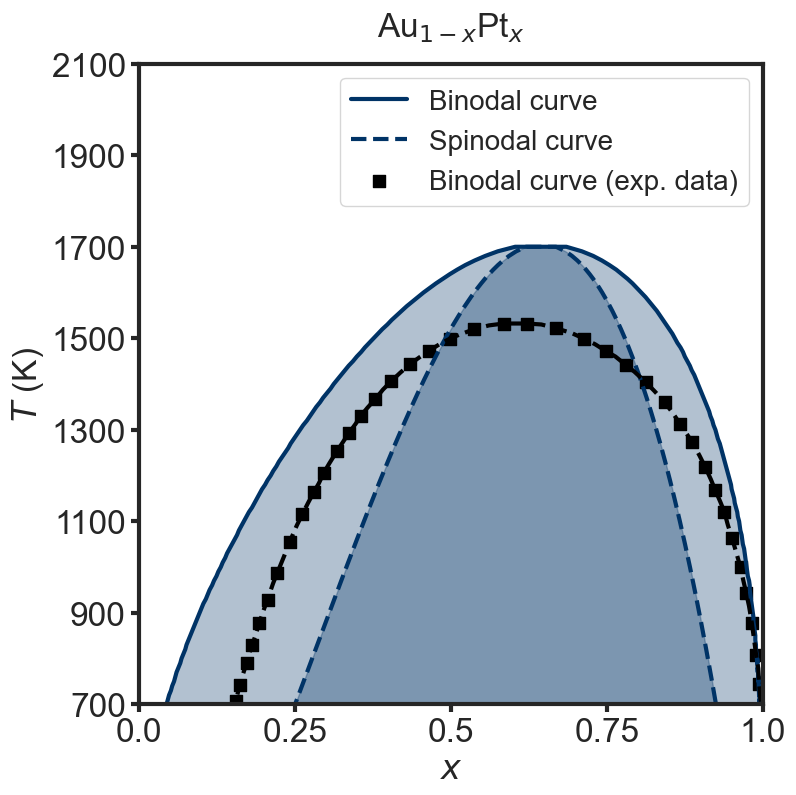

In [20]:
fig, ax = plt.subplots(figsize=(8,8))

fontsize=24
lw=3
# colors = sns.color_palette("RdBu_r", n_colors=ntemp)
color_binodal = "#003366"
color_spinodal = "#003366"
transparency = 0.3

ax.plot(binodal_curve['x'], binodal_curve['t'], linestyle='-', color=color_binodal, lw=lw, label='Binodal curve')
ax.plot(spinodal_curve['x'], spinodal_curve['t'], linestyle='--', color=color_spinodal, lw=lw, label='Spinodal curve')
ax.fill_between(binodal_curve['x'], binodal_curve['t'], color=color_binodal, alpha=transparency)
ax.fill_between(spinodal_curve['x'], spinodal_curve['t'], color=color_spinodal, alpha=transparency)

# experimental data
exp_solvus = pd.read_csv("../../experimental_data/phase_diagram/binodal_AuPt.csv")
ax.plot(exp_solvus["x"], exp_solvus["t"], linestyle="--", color="black", markersize=8, linewidth=lw)
ax.scatter(exp_solvus["x"][::2], exp_solvus["t"][::2], s=64, color="black", marker="s", label="Binodal curve (exp. data)") # square markers

ax.set_xlabel("$x$", fontsize=fontsize)
ax.set_ylabel(r"$T$ (K)" , fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_ylim(700, 2100)
ax.set_xticks(np.linspace(0, 1, 5))
ax.set_xticklabels(np.linspace(0, 1, 5), fontsize=fontsize)
ax.set_yticks(np.arange(700, 2101, 200))
ax.set_yticklabels(np.arange(700, 2101, 200), fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=fontsize, width=lw, length=6, direction='out')
for spine in ax.spines.values():
    spine.set_linewidth(lw)

plt.title(r"Au$_{1-x}$Pt$_{x}$", fontsize=24, pad=20)
plt.legend(loc="best", fontsize=20)
plt.tight_layout()
fig.savefig('phase_diagram.png', dpi=600, bbox_inches='tight')
plt.show()

# Quasichemical Approximation (QCA) model

In [17]:
enthalpy_matrix = np.tile(enthalpy, (ntemp, 1)).T
enthalpy_df = pd.DataFrame(enthalpy_matrix, index=x, columns=temperatures, dtype=np.float64)
enthalpy_df.index.name = 'x'
enthalpy_df.columns.name = 't'
enthalpy_df.to_csv("enthalpy_of_mixing.csv")

# enthalpy_df = pd.DataFrame({"x": x, "enthalpy": enthalpy})
# enthalpy_df.to_csv("enthalpy_of_mixing.csv", index=False)

In [18]:
model_qca = onca.QCABinary(coordination_number=12, enthalpy_df= enthalpy_df)

In [21]:
omega = model_qca.omega()

In [23]:
gamma = model_qca.gamma()

In [29]:
wc_ab, wc_aa, wc_bb = model_qca.warren_cowley_parameters()

In [31]:
h_qca = model_qca.get_enthalpy_of_mixing()

In [62]:
s_qca = model_qca.get_entropy_of_mixing()

In [90]:
temperatures[range(ntemp)[50:-1:10]]

array([ 500.,  600.,  700.,  800.,  900., 1000., 1100., 1200., 1300.,
       1400., 1500., 1600., 1700., 1800., 1900.])

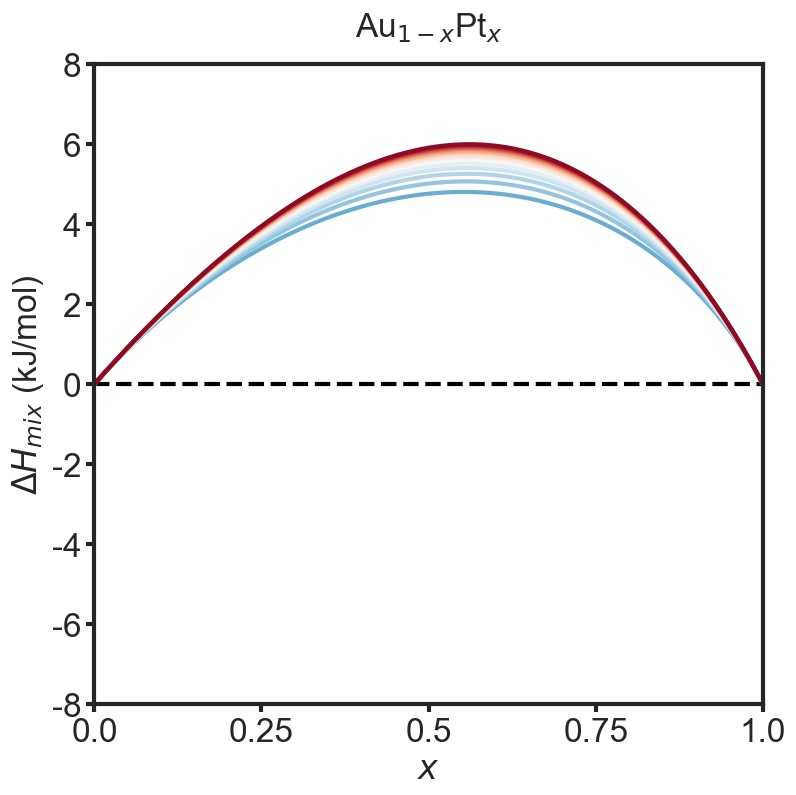

In [93]:
fig, ax = plt.subplots(figsize=(8,8))
color1 = "#1834A0"
lw = 3
fontsize = 24

ntemp = h_qca.shape[1]

x = np.linspace(0, 1, h_qca.shape[0])
colors = sns.color_palette("RdBu_r", n_colors=ntemp)              # Options: "RdBu_r", "coolwarm"

# Baseline black dased line at G=0
ax.axhline(0, color='black', linestyle='--', linewidth=lw, zorder=1)

every = 50
for iT in range(ntemp)[50:-1:10]:                                        # Plot every n temperatures for clarity
    ax.plot(x, h_qca.values[:, iT], color=colors[iT], lw=lw, alpha=1.0)
    # x_pos = 0.25 + iT/ntemp * 0.1                                    # Position the label along the x-axis
    # y_pos = np.interp(x_pos, x, h_qca.values[:, iT]) + 0.2      # Interpolate to find the y position at x_pos
    # ax.text(x_pos, y_pos , str(int(temperatures[iT])), 
    #         color=colors[iT], 
    #         fontsize=14,
    #         fontweight='bold',
    #         ha='center',
    #         va='center',
    #         backgroundcolor='white',
    #         bbox=dict(facecolor='white', edgecolor='white', pad=2.0, alpha=1.0))

ax.set_xlabel(r"$x$", fontsize=fontsize)
ax.set_ylabel(r"$\Delta H_{mix}$ (kJ/mol)", fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_xticks(np.linspace(0, 1, 5))
ax.set_xticklabels(np.linspace(0, 1, 5), fontsize=fontsize)

emin, emax = -10, 10
estep = 2
ax.set_yticks(np.arange(emin, emax, estep))
ax.set_yticklabels(np.arange(emin, emax, estep), fontsize=fontsize)

plt.title(r"Au$_{1-x}$Pt$_{x}$", fontsize=24, pad=20)
# ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=fontsize, width=lw, length=6, direction='out')
for spine in ax.spines.values():
    spine.set_linewidth(lw)

ax.set_xlabel("$x$", fontsize=fontsize)
ax.set_ylabel(r"$\Delta H_{mix}$ (kJ/mol)", fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_ylim(-8,8)

plt.tight_layout()
plt.show()

(-1.0, 1.0)

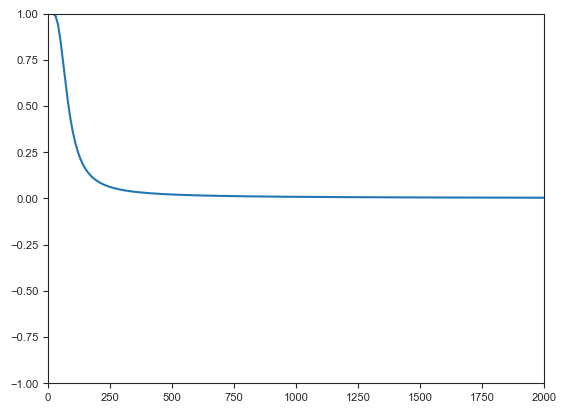

In [106]:
plt.plot(temperatures, wc_ab.values[20])
plt.xlim(0, 2000)
plt.ylim(-1,1)

# Vibrational properties